# Cis-/trans- interactions calculation

### Load Hi-C cool files (250kb resolution)

In [1]:
import cooltools
import cooler
from tqdm import tqdm
from os.path import basename, splitext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections.abc import Iterable
import bioframe
import gc
import subprocess
import itertools
import pysam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import seaborn as sns

In [2]:
wt_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_250k/balsampled_Adult_250k.cool')
old_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_250k/balsampled_Old_250k.cool')
ko_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_250k/balsampled_S6-KO_250k.cool')

CLRS = [wt_clr, old_clr, ko_clr]
LBLS = ['Adult', 'Old', 'S6-KO']

### Define the function to compute cis- and trans- contacts

In [3]:
def compute_cis_trans(hiclist, dropdiag=2, resolution=100000, stable=True, normalized=False):
    """
    This function returns a dictionary where keys are names of Hi-C matrices
    and values are matrices of cis-trans contact sums.
    
    hiclist :: [str] - list of paths to .mcool files
    dropdiag :: int - number of diags to drop (main diagonal counts from 1)
    resolution :: int - desired resolution for Hi-C matrix
    stable :: bool - whether to add 1 to contact sums matrix (for numerical 
                     stability at logarithm computation)
    normalized :: bool - whether to normalize matrix with a total sum of contacts
    """
    interchrom = {}
    for clr in CLRS:
        
        
        sizes = np.array(clr.chromsizes.values) / resolution #compute normalization matrix
        #norm = np.outer(sizes, sizes)

        pix = clr.pixels()[:]
        pix_no_diag = pix[pix.bin2_id >= pix.bin1_id + dropdiag] #delete m first diagonals
        bins = clr.bins()[:].drop(['start', 'end'], axis = 1)

        cis_trans = np.asarray(
                    pix_no_diag.merge(bins, left_on='bin1_id', right_index=True).\
                                merge(bins, left_on='bin2_id', right_index=True).\
                                groupby(['chrom_x', 'chrom_y']).sum().\
                                unstack(fill_value=0)['count']) #convert to square matrix

        cis_trans = cis_trans + cis_trans.T - np.diag(np.diag(cis_trans))
        if stable:
            cis_trans += 1
        if normalized:
            fullsum = np.nansum(cis_trans)
            if fullsum == 0.:
                print('Drop %s due to zero contact sum' % path)
                continue
            cis_trans = cis_trans / fullsum * 2 * 1_000_000 #scale by constant
        result = cis_trans #/ norm
        interchrom[splitext(basename(clr.filename))[0]] = result
    return interchrom

In [4]:
interactions = compute_cis_trans(CLRS, dropdiag=0, resolution=250_000, stable=True, normalized=False)
interactions = dict(zip(['_'.join(k.split('_')[1:2]) for k in interactions.keys()], interactions.values()))

### Analyze the ratio of interactions and collect data for plotting

In [5]:
pairs = [('Old','Adult'), ('S6-KO','Adult')]
statvals_cis = pd.DataFrame()
statvals_trs = pd.DataFrame()

for pair in pairs:
    map1 = interactions[pair[0]]
    map2 = interactions[pair[1]]
    m = map1 / map2
    
    # For boxplots
    statvals_cis[pair[0] + '/' + pair[1]] = m.diagonal()
    statvals_trs[pair[0] + '/' + pair[1]] = m[np.triu_indices_from(m, k=1)]
    cis = pd.melt(statvals_cis)
    trans = pd.melt(statvals_trs)

In [6]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


Saving 6.67 x 6.67 in image


In addition: Warning messages:
1: Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`). 
2: Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`). 


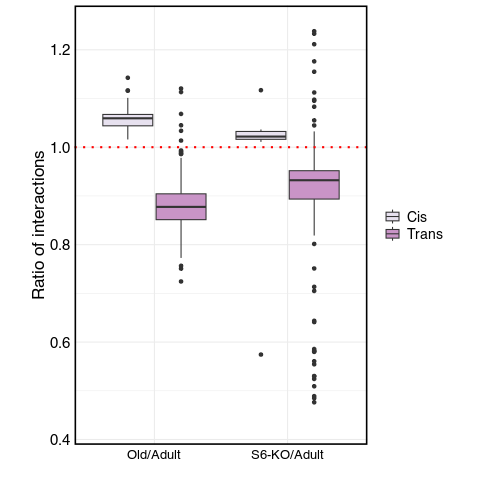

In [15]:
%%R
library(reticulate)
library(ggplot2)
library(scales)

cis <- reticulate::py_eval("cis")
trans <- reticulate::py_eval("trans")
cis$type <- 'Cis'
trans$type <- 'Trans'
df <- rbind(cis, trans)
df$variable <- factor(df$variable, levels=c('Old/Adult', 'S6-KO/Adult'))

p <- ggplot(df, aes(variable, value)) +
  geom_boxplot(position = position_dodge(0.8), aes(fill = type)) +
  theme_minimal() +
  geom_hline(yintercept=1, linetype='dotted', col = 'red', size=1) +
  xlab("") + ylab("Ratio of interactions") +
  scale_fill_brewer(palette="PuRd") +
  scale_y_continuous(
    limits = c(0.43, 1.25),
    breaks = pretty_breaks(n = 5)
  ) +
  theme(axis.text.x = element_text(size = 13, colour = 'black'),
        axis.text.y = element_text(size = 15, colour = 'black'),
        axis.title.y = element_text(size = 17, colour='black'),
        legend.title = element_blank(),
        legend.text = element_text(size=14),
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 1.5/1)

print(p)

ggsave('cis_trans_ratio.pdf', p, dpi=1200)

In [13]:
cis_interactions = pd.DataFrame()
trans_interactions = pd.DataFrame()

conditions = ['Old', 'Adult', 'S6-KO']

for condition in conditions:
    mat = interactions[condition]
    
    # Extract cis interactions (diagonal elements)
    cis_interactions[condition] = mat.diagonal()
    
    # Extract trans interactions (upper triangle excluding diagonal)
    trans_interactions[condition] = mat[np.triu_indices_from(mat, k=1)]

cis_melted = pd.melt(cis_interactions)
trans_melted = pd.melt(trans_interactions)

In [28]:
%%R

cis <- reticulate::py_eval("cis_melted")
trans <- reticulate::py_eval("trans_melted")
cis$type <- 'Cis'
trans$type <- 'Trans'

cis_adult <- subset(cis, variable == 'Adult')
cis_old <- subset(cis, variable == 'Old')
cis_s6_ko <- subset(cis, variable == 'S6-KO') 

trans_adult <- subset(trans, variable == 'Adult')
trans_old <- subset(trans, variable == 'Old')
trans_s6_ko <- subset(trans, variable == 'S6-KO')

comparisons <- list(
  c('Adult', 'Old'),
  c('Adult', 'S6_KO')  
)

results <- data.frame()

for (type in c('cis', 'trans')) {
  for (pair in comparisons) {
    cond1 <- pair[1]
    cond2 <- pair[2]

    lookup_cond1 <- tolower(cond1)
    lookup_cond2 <- tolower(gsub("-", "_", cond2))
    
    data1 <- get(paste0(type, "_", lookup_cond1))
    data2 <- get(paste0(type, "_", lookup_cond2))
    
    test_result <- wilcox.test(data1$value, data2$value, paired = TRUE)
    
    results <- rbind(results, data.frame(
      comparison = paste(gsub("_", "-", cond1), "vs", gsub("_", "-", cond2)), 
      type = type,
      p.value = test_result$p.value,
      statistic = test_result$statistic,
      stringsAsFactors = FALSE
    ))
  }
}

print(results)

       comparison  type      p.value statistic
V    Adult vs Old   cis 9.536743e-07         0
V1 Adult vs S6-KO   cis 1.907349e-06         1
V2   Adult vs Old trans 1.974205e-35     22030
V3 Adult vs S6-KO trans 7.532136e-27     20536


## Cis/trans ratio for replicates

In [30]:
import cooler
import numpy as np
import pandas as pd

CLRS = [
    cooler.Cooler('/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_adl_m_1_25k.cool'),
    cooler.Cooler('/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_adl_f_2_25k.cool'),
    cooler.Cooler('/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_adl_f_3_25k.cool'),
    cooler.Cooler('/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_old_m_1_25k.cool'),
    cooler.Cooler('/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_old_f_2_25k.cool'),
    cooler.Cooler('/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_old_f_3_25k.cool'),
    cooler.Cooler('/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_KO_m_1_25k.cool'),
    cooler.Cooler('/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_KO_f_2_25k.cool'),
    cooler.Cooler('/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_KO_f_3_25k.cool'),
]
LBLS = ['adl_m_1', 'adl_f_2', 'adl_f_3',
        'old_m_1', 'old_f_2', 'old_f_3',
        'KO_m_1',  'KO_f_2',  'KO_f_3']

GROUP_MAP = {
    'adl_m_1': 'Adult', 'adl_f_2': 'Adult', 'adl_f_3': 'Adult',
    'old_m_1': 'Old',   'old_f_2': 'Old',   'old_f_3': 'Old',
    'KO_m_1':  'S6-KO', 'KO_f_2':  'S6-KO', 'KO_f_3':  'S6-KO',
}

def compute_cis_trans_individual(clr_list, labels, dropdiag=0, stable=True):
    results = {}
    for clr, label in zip(clr_list, labels):
        pix = clr.pixels()[:]
        pix_no_diag = pix[pix.bin2_id >= pix.bin1_id + dropdiag]
        bins = clr.bins()[:].drop(['start', 'end'], axis=1)
        cis_trans = np.asarray(
            pix_no_diag
            .merge(bins, left_on='bin1_id', right_index=True)
            .merge(bins, left_on='bin2_id', right_index=True)
            .groupby(['chrom_x', 'chrom_y'])
            .sum()
            .unstack(fill_value=0)['count']
        )
        cis_trans = cis_trans + cis_trans.T - np.diag(np.diag(cis_trans))
        if stable:
            cis_trans += 1
        results[label] = cis_trans
    return results

interactions = compute_cis_trans_individual(CLRS, LBLS)

statvals_cis   = pd.DataFrame()
statvals_trans = pd.DataFrame()
for label, matrix in interactions.items():
    statvals_cis[label]   = matrix.diagonal()
    statvals_trans[label] = matrix[np.triu_indices_from(matrix, k=1)]

cis   = pd.melt(statvals_cis,   var_name='variable', value_name='value')
trans = pd.melt(statvals_trans, var_name='variable', value_name='value')
cis['type']   = 'Cis'
trans['type'] = 'Trans'
df = pd.concat([cis, trans])
df['group'] = df['variable'].map(GROUP_MAP)

Saving 6.67 x 6.67 in image


In addition: Warning message:
In py_to_r.pandas.core.frame.DataFrame(<environment>) :
  index contains duplicated values: row names not set


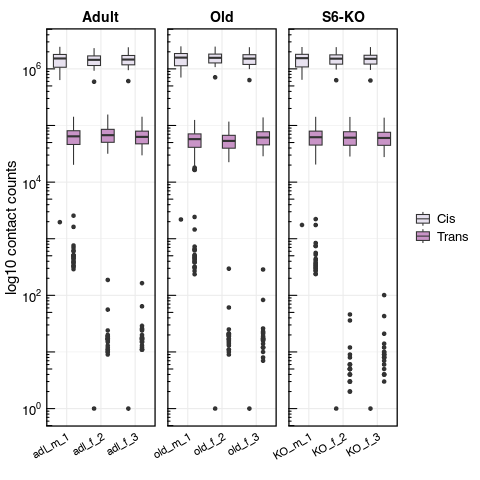

In [33]:
%%R
library(reticulate)
library(ggplot2)
library(scales)

df <- reticulate::py_eval("df")

sample_order <- c('adl_m_1','adl_f_2','adl_f_3',
                  'old_m_1','old_f_2','old_f_3',
                  'KO_m_1', 'KO_f_2', 'KO_f_3')
df$variable <- factor(df$variable, levels = sample_order)
df$group    <- factor(df$group,    levels = c('Adult', 'Old', 'S6-KO'))

p <- ggplot(df, aes(variable, value, fill = type)) +
  geom_boxplot(position = position_dodge(0.8)) +
  facet_grid(~ group, scales = 'free_x', space = 'free_x') +
  theme_minimal() +
  xlab("") +
  ylab("log10 contact counts") +
  scale_fill_brewer(palette = "PuRd") +
  scale_y_log10(
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
  ) +
  annotation_logticks(sides = "l") +
  theme(
    strip.text       = element_text(size = 14, colour = 'black', face = 'bold'),
    axis.text.x      = element_text(size = 11, colour = 'black', angle = 30, hjust = 1),
    axis.text.y      = element_text(size = 13, colour = 'black'),
    axis.title.y     = element_text(size = 15, colour = 'black'),
    legend.title     = element_blank(),
    legend.text      = element_text(size = 13),
    panel.border     = element_rect(colour = "black", fill = NA, size = 1.2),
    panel.spacing    = unit(0.8, "lines")
  )
print(p)

#ggsave('cis_trans_ratio_rep.pdf', p, dpi=1200)

In [32]:
%%R
library(dplyr)

bootstrap_median_test <- function(x, y, R = 9999) {
  obs_diff <- median(x) - median(y)
  pooled   <- c(x, y)
  nx       <- length(x)
  boot_diffs <- replicate(R, {
    idx      <- sample(length(pooled), nx, replace = FALSE)
    sample_x <- pooled[idx]
    sample_y <- pooled[-idx]
    median(sample_x) - median(sample_y)
  })
  list(median_diff = obs_diff,
       p.value     = mean(abs(boot_diffs) >= abs(obs_diff)))
}

pairwise_bootstrap <- function(df, type_name, group_name, R = 9999) {
  sub  <- df %>% filter(type == type_name, group == group_name)
  vars <- unique(as.character(sub$variable))
  pairs <- combn(vars, 2, simplify = FALSE)
  bind_rows(lapply(pairs, function(pair) {
    x    <- sub$value[sub$variable == pair[1]]
    y    <- sub$value[sub$variable == pair[2]]
    test <- bootstrap_median_test(x, y, R = R)
    data.frame(group       = group_name,
               type        = type_name,
               group1      = pair[1],
               group2      = pair[2],
               median_diff = test$median_diff,
               p.value     = test$p.value)
  }))
}

set.seed(42)
conditions <- c('Adult', 'Old', 'S6-KO')
types      <- c('Cis', 'Trans')

results <- bind_rows(lapply(conditions, function(g) {
  bind_rows(lapply(types, function(t) {
    pairwise_bootstrap(df, t, g)
  }))
}))

results$p.adj <- p.adjust(results$p.value, method = "BH")
print(results)

   group  type  group1  group2 median_diff    p.value      p.adj
1  Adult   Cis adl_m_1 adl_f_2     82554.0 0.76737674 0.91347885
2  Adult   Cis adl_m_1 adl_f_3     65035.0 0.76187619 0.91347885
3  Adult   Cis adl_f_2 adl_f_3    -17519.0 0.81198120 0.91347885
4  Adult Trans adl_m_1 adl_f_2     -3092.5 0.15491549 0.55769577
5  Adult Trans adl_m_1 adl_f_3      1454.5 0.55545555 0.91347885
6  Adult Trans adl_f_2 adl_f_3      4547.0 0.08840884 0.39783978
7    Old   Cis old_m_1 old_f_2     13973.0 1.00000000 1.00000000
8    Old   Cis old_m_1 old_f_3     63441.0 0.76107611 0.91347885
9    Old   Cis old_f_2 old_f_3     49468.0 0.78727873 0.91347885
10   Old Trans old_m_1 old_f_2      4050.5 0.05130513 0.30783078
11   Old Trans old_m_1 old_f_3     -3874.5 0.03270327 0.29432943
12   Old Trans old_f_2 old_f_3     -7925.0 0.00040004 0.00720072
13 S6-KO   Cis  KO_m_1  KO_f_2     32175.0 0.81038104 0.91347885
14 S6-KO   Cis  KO_m_1  KO_f_3     40958.0 0.76747675 0.91347885
15 S6-KO   Cis  KO_f_2  K

In [34]:
ALL_CLRS = {
    'adl_m_1': '/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_adl_m_1_25k.cool',
    'adl_f_2': '/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_adl_f_2_25k.cool',
    'adl_f_3': '/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_adl_f_3_25k.cool',
    'old_m_1': '/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_old_m_1_25k.cool',
    'old_f_2': '/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_old_f_2_25k.cool',
    'old_f_3': '/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_old_f_3_25k.cool',
    'KO_m_1':  '/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_KO_m_1_25k.cool',
    'KO_f_2':  '/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_KO_f_2_25k.cool',
    'KO_f_3':  '/tank/projects/kashuk_sirt6_hic/downsampled_250k/bal_sampled_KO_f_3_25k.cool',
}

records = []
for label, path in ALL_CLRS.items():
    clr = cooler.Cooler(path)
    pixels = clr.pixels()[:]
    bins = clr.bins()[:]
    pix_ann = (pixels
        .merge(bins[['chrom']], left_on='bin1_id', right_index=True)
        .merge(bins[['chrom']], left_on='bin2_id', right_index=True)
    )
    total = pixels['count'].sum()
    cis   = pix_ann[pix_ann['chrom_x'] == pix_ann['chrom_y']]['count'].sum()
    trans = pix_ann[pix_ann['chrom_x'] != pix_ann['chrom_y']]['count'].sum()
    records.append({
        'sample': label,
        'group': label.split('_')[0],  # adl / old / KO
        'pct_trans': 100 * trans / total,
        'pct_cis':   100 * cis / total,
    })

summary_df = pd.DataFrame(records)
print(summary_df.to_string())

    sample group  pct_trans    pct_cis
0  adl_m_1   adl  30.458632  69.541368
1  adl_f_2   adl  32.928797  67.071203
2  adl_f_3   adl  30.701676  69.298324
3  old_m_1   old  26.865185  73.134815
4  old_f_2   old  25.779674  74.220326
5  old_f_3   old  29.607827  70.392173
6   KO_m_1    KO  29.826077  70.173923
7   KO_f_2    KO  29.714698  70.285302
8   KO_f_3    KO  29.310834  70.689166
